In [2]:
from brian2 import *
from dataclasses import dataclass, field
from typing import Dict, Optional, List, Callable
import numpy as np
import pandas as pd
import sys
import glob
import os
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 1000  # in MB
print(sys.version)

sys.path.insert(0, "/Users/k2585057/Dropbox/PhD/Analysis/my_scripts/GitHub/gene_snn/")
sys.path.insert(0, "/Users/k2585057/Dropbox/PhD/Analysis/my_scripts/GitHub/neuropix_process/sig/")
sys.path.insert(0, "/Users/k2585057/Dropbox/PhD/Analysis/my_scripts/GitHub/neuropix_process/visualise/")
from model_builder import *
from model_params import *
import visualise as vif
import process as prf
import firing_metrics as fif


cpath = '/Users/k2585057/Library/CloudStorage/Dropbox/PhD/Analysis/my_scripts/GitHub/region_analysis/'
dpath = '/Users/k2585057/Library/CloudStorage/Dropbox/PhD/Analysis/Project/'
%load_ext autoreload

3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 18:02:02) 
[Clang 18.1.8 ]
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Link between PR and E

In [10]:
#Key parameters
pars = {
    'spike_threshold_u': -50,
    'spike_threshold_sigma': 5,
    'rmp_u': -70,
    'rmp_sigma': 1,

    'synaptic_delay_u': 1.0,
    'synaptic_delay_sigma': 0.15, # add jitter to kill volleys

    'tau_excitatory_u': 12,       # E a bit slower
    'tau_inhibitory_u': 6,        # I faster → desynchronizes
    'tau_sigma': 2,
    'refractory_excitatory_u': 2.0,
    'refractory_inhibitory_u': 1.0,
    'refractory_sigma': 0.5,


    'excitatory_size': int(1000),
    'inhibitory_size': int(400),

    #k, E and I inputs per neuron -> K must be largee enough so that 1/rootK is small

    #NB is this sufficiently sparse
    #NB is K large enough but small enough compared to total network size
    'e-e_connectivity_p': 0.05,   # halve E→E indegree to reduce synchrony
    'e-i_connectivity_p': 0.08,
    'i-e_connectivity_p': 0.25,
    'i-i_connectivity_p': 0.20,   # slightly lower I→I to avoid inhibitory locking


    #synaptic input fluctuations - root K synaptic inputs needed to cross the threshold (rootK=10)
    #RMP -> threshold = 20mV
    #so weight should be ~2mv
    'e-e_synw_u': 3.5,
    'e-i_synw_u': 1.9,
    'i-e_synw_u': 2.1,            # inhibitory onto E slightly stronger than E→E
    'i-i_synw_u': 1.7,
    'synw_sigma': 0.3,            # more heterogeneity (helps decorrelate)
    
    
    #external inputs - on average K inputs per neuron

    'PI_size': 1000,
    'PI_p': 0.1,
    'PI_rates_u_excitatory': 8,
    'PI_rates_u_inhibitory': 8,
    'PI_rates_sigma': 0.1,
    'PI_weights_sigma': 0.2,
    'PI_weights_u_excitatory': 1.0,
    'PI_weights_u_inhibitory': 1.0   
}

# var_pars = {
#     # connectivity




#     'PI_size': 1000,
#     'PI_p': 0.1,
#     'PI_rates_u_excitatory': 8,
#     'PI_rates_u_inhibitory': 8,
#     'PI_rates_sigma': 0.1,
#     'PI_weights_sigma': 0.2,
#     'PI_weights_u_excitatory': 1.0,
#     'PI_weights_u_inhibitory': 1.0   
# }

#pars.update(var_pars)

In [21]:
%%time 
#Vanilla-selfI network: E->E;E->I;I->E; I->I
#=================================

def _run(pars):
    #Vanilla-selfI network: E->E;E->I;I->E; I->I
    #=================================
    
    # Reset Brian2
    b2.start_scope()
    SEED = 42
    b2.seed(SEED); np.random.seed(SEED)
    
    sim_time=60.0*second
    warmup=1.0*second
    
    # ---- build network ----
    
    #Access braintype container with all model parts
    model = braintype(pars = pars)
    model.DE(); model.neuron(); model.population(); model.region(); model.synapse()
    
    #Combine our specific parts into shared registry
    R = Registry()
    R.add_mechanism(model.lif_dyn); R.add_mechanism(model.dirsyn_dyn)
    R.add_neuron(model.exc_nrn); R.add_neuron(model.inh_nrn)
    R.add_population(model.cort_exc_pop); R.add_population(model.cort_inh_pop)
    R.add_region(model.cort_reg)
    R.add_synapse(model.ee_syn); R.add_synapse(model.ei_syn); R.add_synapse(model.ie_syn); R.add_synapse(model.ii_syn)
    
    #Build Brian2 network
    builder = BrianBuilder(R, default_dt=0.1*b2.ms, default_method='heun')
    E = builder.build_population("cortical_excitatory")
    I = builder.build_population("cortical_inhibitory")
    builder.build_synapse("cortical_excitatory_to_cortical_excitatory")
    builder.build_synapse("cortical_excitatory_to_cortical_inhibitory")
    builder.build_synapse("cortical_inhibitory_to_cortical_excitatory")
    builder.build_synapse("cortical_inhibitory_to_cortical_inhibitory")
    
    
    # Warmup
    builder.net.run(warmup)
    
    # Monitors
    spk_E = b2.SpikeMonitor(E); spk_I = b2.SpikeMonitor(I)
    builder.net.add(spk_E, spk_I)
    
    # Main run
    builder.net.run(sim_time)
    
    # # Bin spikes
    rate = 100  # Hz bins
    n_time = int(rate * sim_time)
    E_mat, _ = prf.bin_b2(
        spike_index=np.array(spk_E.i),
        spike_times=np.array(spk_E.t - warmup),
        rate=rate, N=spk_E.source.N, n_time=n_time
    )
    I_mat, _ = prf.bin_b2(
        spike_index=np.array(spk_I.i),
        spike_times=np.array(spk_I.t - warmup),
        rate=rate, N=spk_I.source.N, n_time=n_time
    )
    return(E_mat, I_mat)

def spk_to_fl(S, dt_native,
                        tau_d=0.7, A=1.0, ksat=1.0,
                        F0=0.0, add_noise=False):
    """
    Quick & dirty GCaMP-like fluorescence from binned spikes.

    Parameters
    ----------
    S : array (N_cells x T)
        Spike counts per bin (can be float32)
    dt_native : float
        Bin width in seconds.
    tau_d : float
        Decay constant (s) for exponential kernel.
    A : float
        Linear amplitude scaling.
    ksat : float
        Saturation factor for F = A*C/(1+ksat*C)
    F0 : float
        Baseline fluorescence offset.
    add_noise : bool
        If True, adds light Gaussian + shot noise.

    Returns
    -------
    F : array (N_cells x T)
        Simulated fluorescence traces (same sampling as input).
    """
    S = np.asarray(S, dtype=np.float32)
    N, T = S.shape

    # simple exponential filter: C_t = (1 - dt/tau)*C_{t-1} + (dt/tau)*S_t
    alpha = np.exp(-dt_native / tau_d)
    C = np.zeros_like(S)
    for t in range(1, T):
        C[:, t] = alpha * C[:, t-1] + (1 - alpha) * S[:, t]

    # saturation + optional noise
    F = F0 + (A * C) / (1.0 + ksat * C)
    if add_noise:
        F += 0.01 * np.random.randn(*F.shape) + \
             0.05 * np.random.randn(*F.shape) * np.sqrt(np.maximum(F, 0))

    return F

from sklearn.decomposition import PCA
def participation_ratio(X):
    # X: cells x time; z-score per cell
    Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    pca = PCA(svd_solver='randomized')
    pca.fit(Xz.T)
    lam = pca.singular_values_**2
    return (lam.sum()**2) / (np.sum(lam**2)), lam

import pandas as pd
import numpy as np
from pyEDM import EmbedDimension

import pandas as pd
import numpy as np
from pyEDM import EmbedDimension

import numpy as np
import pandas as pd
from pyEDM import EmbedDimension
from tqdm import tqdm

def E_from_pcs(
    PCs,
    maxE=20,
    Tp=1,
    tau=10,
    lib_frac=0.6,
    exclusionRadius=0,
    numProcess=1,   # keep 1 inside each call to avoid mp conflicts in loops
    showPlot=False,
    verbose=False
):
    """
    Estimate embedding dimension E* separately for each PC time series (univariate EDM).

    Parameters
    ----------
    PCs : array-like, shape (T, K)
        Time-series matrix: rows=time, cols=PC1..PCK.
    maxE : int
        Max embedding dimension to test (E = 1..maxE).
    Tp : int
        Prediction horizon.
    tau : int
        Delay (in samples).
    lib_frac : float
        Fraction of samples used for library (rest for prediction).
    exclusionRadius : int
        Exclusion radius for prediction vectors.
    numProcess : int
        Processes per pyEDM call (set >1 if your platform handles it well).
    showPlot : bool
        Show pyEDM plot per PC (usually False when looping).
    verbose : bool
        Verbose pyEDM output.

    Returns
    -------
    E_per_pc : np.ndarray, shape (K,)
        Best embedding dimension for each PC (PC1..PCK).
    rho_per_pc : np.ndarray, shape (K,)
        Max prediction skill ρ for each PC.
    tables : list of pd.DataFrame
        Full EmbedDimension outputs per PC (each has columns E, rho).
    """
    PCs = np.asarray(PCs)
    T, K = PCs.shape

    # Build base DataFrame with Time + all PCs (we'll point to one column at a time)
    df = pd.DataFrame(PCs, columns=[f"PC{i+1}" for i in range(K)])
    df.insert(0, "Time", np.arange(T))

    split = int(lib_frac * T)
    split = max(min(split, T - 5), 10)  # keep both lib & pred non-trivial
    lib = f"1 {split}"
    pred = f"{split+1} {T}"

    E_per_pc  = np.full(K, np.nan, dtype=float)
    rho_per_pc = np.full(K, np.nan, dtype=float)
    tables = []

    # Loop over PCs, univariate EDM per target
    for k in range(K):
        target_col = f"PC{k+1}"
        try:
            out = EmbedDimension(
                dataFrame=df,
                columns=target_col,          # univariate library = target PC only
                target=target_col,
                maxE=maxE,
                lib=lib,
                pred=pred,
                Tp=Tp,
                tau=tau,
                exclusionRadius=exclusionRadius,
                embedded=False,
                numProcess=numProcess,
                showPlot=showPlot,
                verbose=verbose
            )
            best_idx = out['rho'].idxmax()
            E_per_pc[k]   = int(out.loc[best_idx, 'E'])
            rho_per_pc[k] = float(out.loc[best_idx, 'rho'])
            tables.append(out)
        except Exception as e:
            if verbose:
                print(f"PC{k+1} failed: {e}")
            tables.append(None)

    return E_per_pc, rho_per_pc, tables



CPU times: user 171 ms, sys: 55.3 ms, total: 226 ms
Wall time: 415 ms


In [7]:
%%time
import scipy.sparse as sp
E_mat, I_mat = _run(pars)
mat = np.array(sp.vstack((E_mat, I_mat)).todense())
fmat = spk_to_fl(S=mat, dt_native=1/100)

WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


CPU times: user 53.4 s, sys: 199 ms, total: 53.6 s
Wall time: 54.7 s


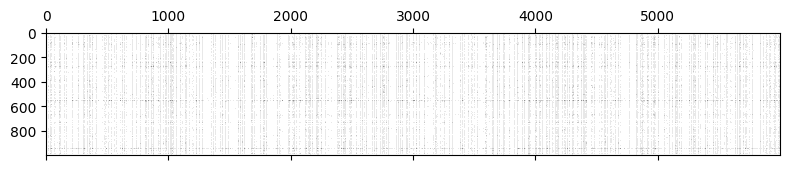

In [8]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(np.array(E_mat.todense()), cmap='Greys')
plt.tight_layout()
plt.show()

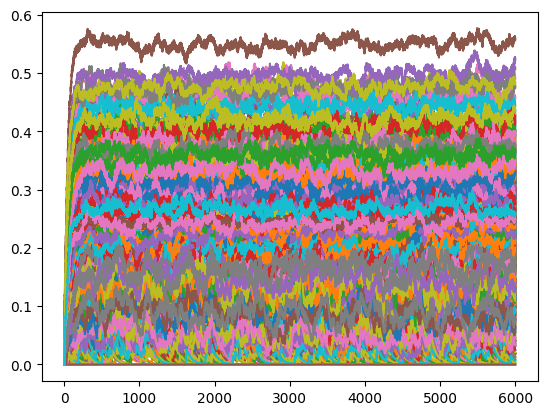

In [50]:
plt.plot(fmat.T)
plt.show()

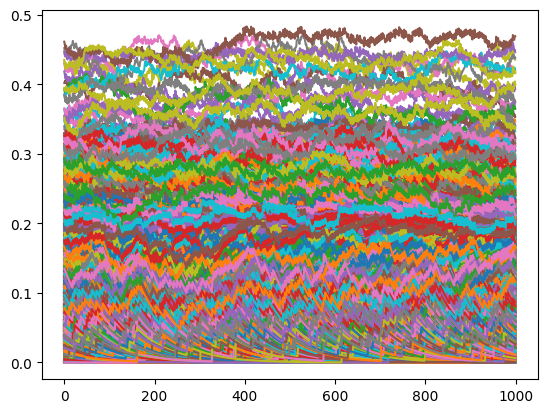

In [44]:
plt.plot(flu_l[0].T[1000:2000])
plt.show()

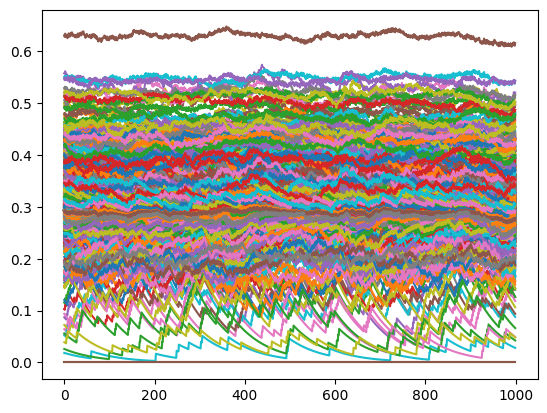

In [45]:
plt.plot(flu_l[3].T[1000:2000])
plt.show()

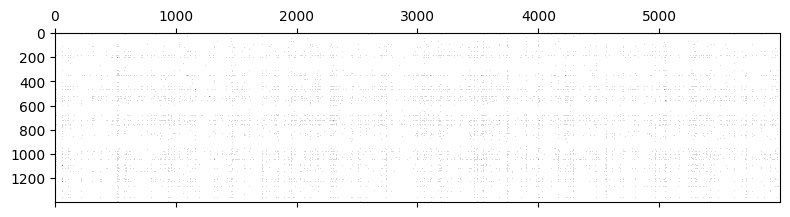

In [37]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(np.array(data_l[1]), cmap='Greys')
plt.tight_layout()
plt.show()

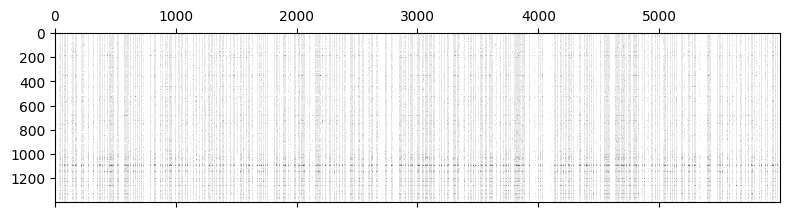

In [36]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(np.array(data_l[3]), cmap='Greys')
plt.tight_layout()
plt.show()

In [10]:
mat.shape

(1400, 6000)

In [17]:
%%time
from tqdm import tqdm
import scipy.sparse as sp

eew_vals = [1, 2, 3, 4.0]
pr_l = []
data_l = []
flu_l = []
for e in tqdm(eew_vals):
    _pars = pars.copy()
    _pars['e-e_synw_u'] = e
    
    E_mat, I_mat = _run(_pars)
    dt_native = 1/100.0
    mat = np.array(sp.vstack((E_mat, I_mat)).todense())
    fmat = spk_to_fl(S=mat, dt_native=1/100)
    PR, _ = participation_ratio(fmat)
    pr_l.append(PR)
    data_l.append(mat)
    flu_l.append(fmat)

100%|██████████████| 4/4 [03:39<00:00, 54.99s/it]

CPU times: user 4min 17s, sys: 4.81 s, total: 4min 22s
Wall time: 3min 39s


In [18]:
pr_l

[58.37152667251883, 47.69178996358743, 6.793943095540929, 1.4103093307998353]

In [10]:
#run
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

E_mat, I_mat = _run(_pars)
dt_native = 1/100.0
mat = np.array(sp.vstack((E_mat, I_mat)).todense())
fmat = spk_to_fl(S=mat, dt_native=1/100)

#estimate PR
PR, _ = participation_ratio(fmat)

#estimate E - for now use tau = 10 on top 10 PCs
X = fmat.T[200:]
sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=10).fit_transform(sc)
out = E_from_pcs(pca)
E = np.mean(out[0])


In [11]:
PR, E

(2.487890395749784, 2.6)

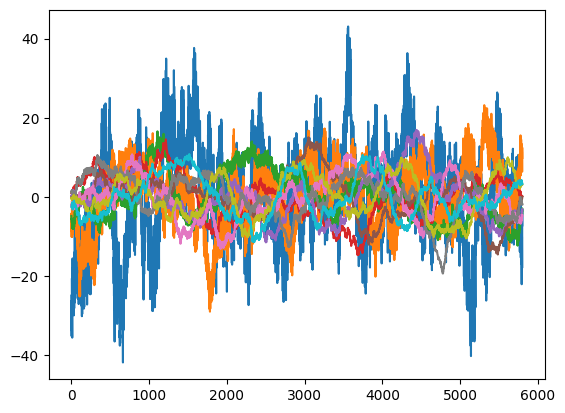

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
plt.plot(pca)
plt.show()

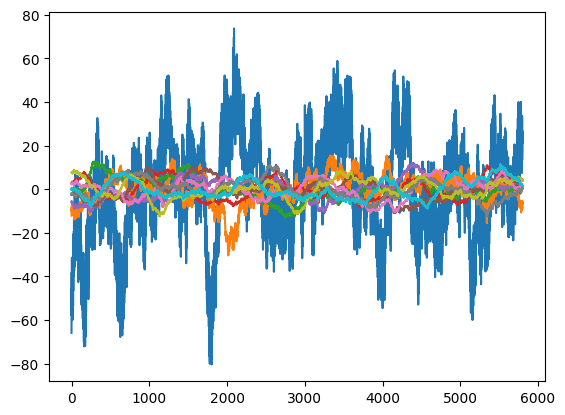

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = flu_l[3].T[200:]
sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=10).fit_transform(sc)
plt.plot(pca)
plt.show()

In [12]:
import numpy as np
import pandas as pd
import itertools
import time
import scipy.sparse as sp
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ======== Your functions ========
# Assumed to exist in your namespace:
#   _run(_pars)
#   spk_to_fl(S, dt_native)
#   participation_ratio(fmat)
#   E_from_pcs(pca)

# ===============================================================
# Base parameters
# ===============================================================
base_pars = {
    'spike_threshold_u': -50,
    'spike_threshold_sigma': 5,
    'rmp_u': -70,
    'rmp_sigma': 1,
    'synaptic_delay_u': 1.0,
    'synaptic_delay_sigma': 0.15,
    'tau_excitatory_u': 12,
    'tau_inhibitory_u': 6,
    'tau_sigma': 2,
    'refractory_excitatory_u': 2.0,
    'refractory_inhibitory_u': 1.0,
    'refractory_sigma': 0.5,
    'excitatory_size': 1000,
    'inhibitory_size': 400,
    'e-e_connectivity_p': 0.05,
    'e-i_connectivity_p': 0.08,
    'i-e_connectivity_p': 0.25,
    'i-i_connectivity_p': 0.20,
    'e-e_synw_u': 3.5,
    'e-i_synw_u': 1.9,
    'i-e_synw_u': 2.1,
    'i-i_synw_u': 1.7,
    'synw_sigma': 0.3,
    'PI_size': 1000,
    'PI_p': 0.1,
    'PI_rates_u_excitatory': 8,
    'PI_rates_u_inhibitory': 8,
    'PI_rates_sigma': 0.1,
    'PI_weights_sigma': 0.2,
    'PI_weights_u_excitatory': 1.0,
    'PI_weights_u_inhibitory': 1.0
}

# ===============================================================
# Parameters to vary and their ranges
# ===============================================================
param_grid = {
    'PI_rates_sigma':      np.linspace(0.05, 0.5, 10),
    'synw_sigma':          np.linspace(0.1, 1.0, 10),
    'e-e_connectivity_p':  np.linspace(0.02, 0.1, 10),
    'i-e_connectivity_p':  np.linspace(0.1, 0.4, 10),
    'e-i_connectivity_p':  np.linspace(0.04, 0.15, 10),
    'i-i_connectivity_p':  np.linspace(0.1, 0.3, 10),
    'synaptic_delay_u':    np.linspace(0.5, 2.0, 10),
    'tau_excitatory_u':    np.linspace(6, 20, 10),
    'tau_inhibitory_u':    np.linspace(3, 12, 10),
}

# ===============================================================
# Core evaluation function
# ===============================================================
def evaluate_param(param_name, value, base_pars):
    pars = base_pars.copy()
    pars[param_name] = value

    try:
        # ---- run network ----
        E_mat, I_mat = _run(pars)
        mat = np.array(sp.vstack((E_mat, I_mat)).todense())
        fmat = spk_to_fl(S=mat, dt_native=1/100)

        # ---- PR ----
        PR, _ = participation_ratio(fmat)

        # ---- E (embedding dimension) ----
        X = fmat.T[200:]
        sc = StandardScaler().fit_transform(X)
        pca = PCA(n_components=10).fit_transform(sc)
        out = E_from_pcs(pca)
        E_mean = np.mean(out['rho_vec']) if isinstance(out, dict) else np.mean(out[0])

        return {'param': param_name, 'value': value, 'PR': PR, 'E': E_mean}

    except Exception as e:
        print(f"Error on {param_name}={value}: {e}")
        return {'param': param_name, 'value': value, 'PR': np.nan, 'E': np.nan}

# ===============================================================
# Parallel grid search
# ===============================================================
def run_grid(param_grid, base_pars, n_jobs=4, save_csv='grid_results.csv'):
    tasks = []
    for param, values in param_grid.items():
        for v in values:
            tasks.append((param, v))

    print(f"Total runs: {len(tasks)}")
    t0 = time.time()

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(evaluate_param)(p, v, base_pars) for p, v in tasks
    )

    df = pd.DataFrame(results)
    df.to_csv(save_csv, index=False)
    print(f"\nGrid complete. Saved to {save_csv}")
    print(f"Elapsed: {(time.time()-t0)/3600:.2f} hours")

    return df

# ===============================================================
# Run overnight grid search
# ===============================================================
if __name__ == "__main__":
    df = run_grid(param_grid, base_pars, n_jobs=4, save_csv='E_PR_grid_results.csv')
    print(df.head())


Total runs: 90


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]
WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch 

Loaded 90 rows after cleaning.



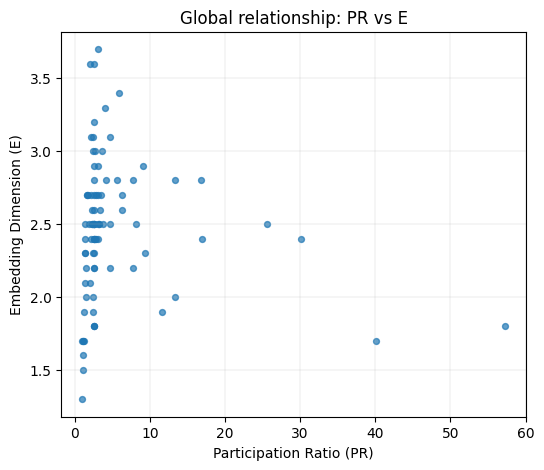

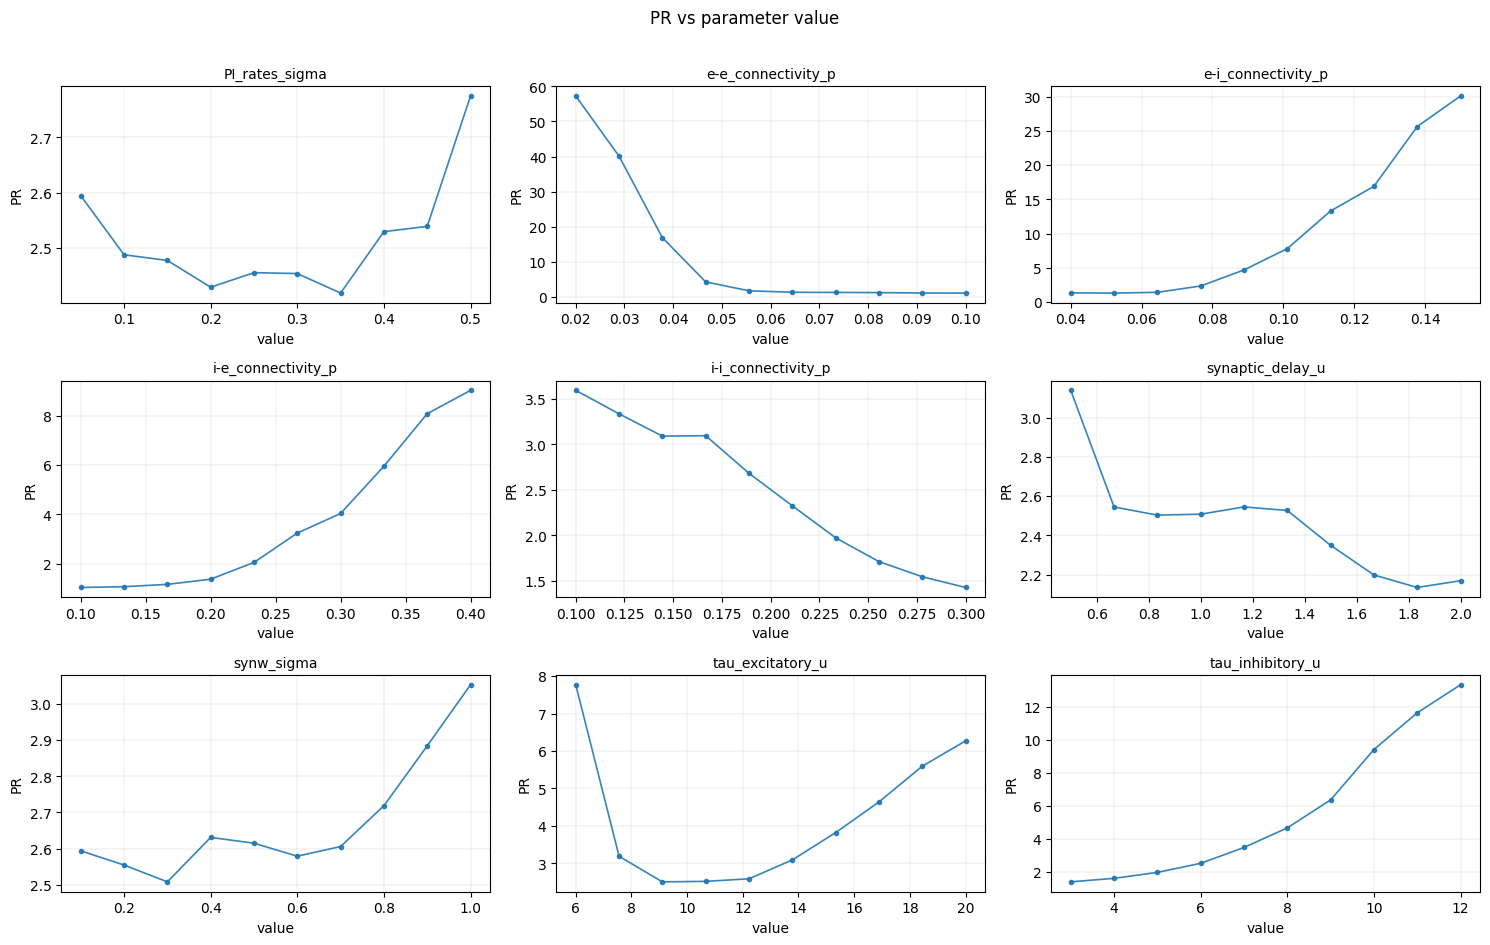

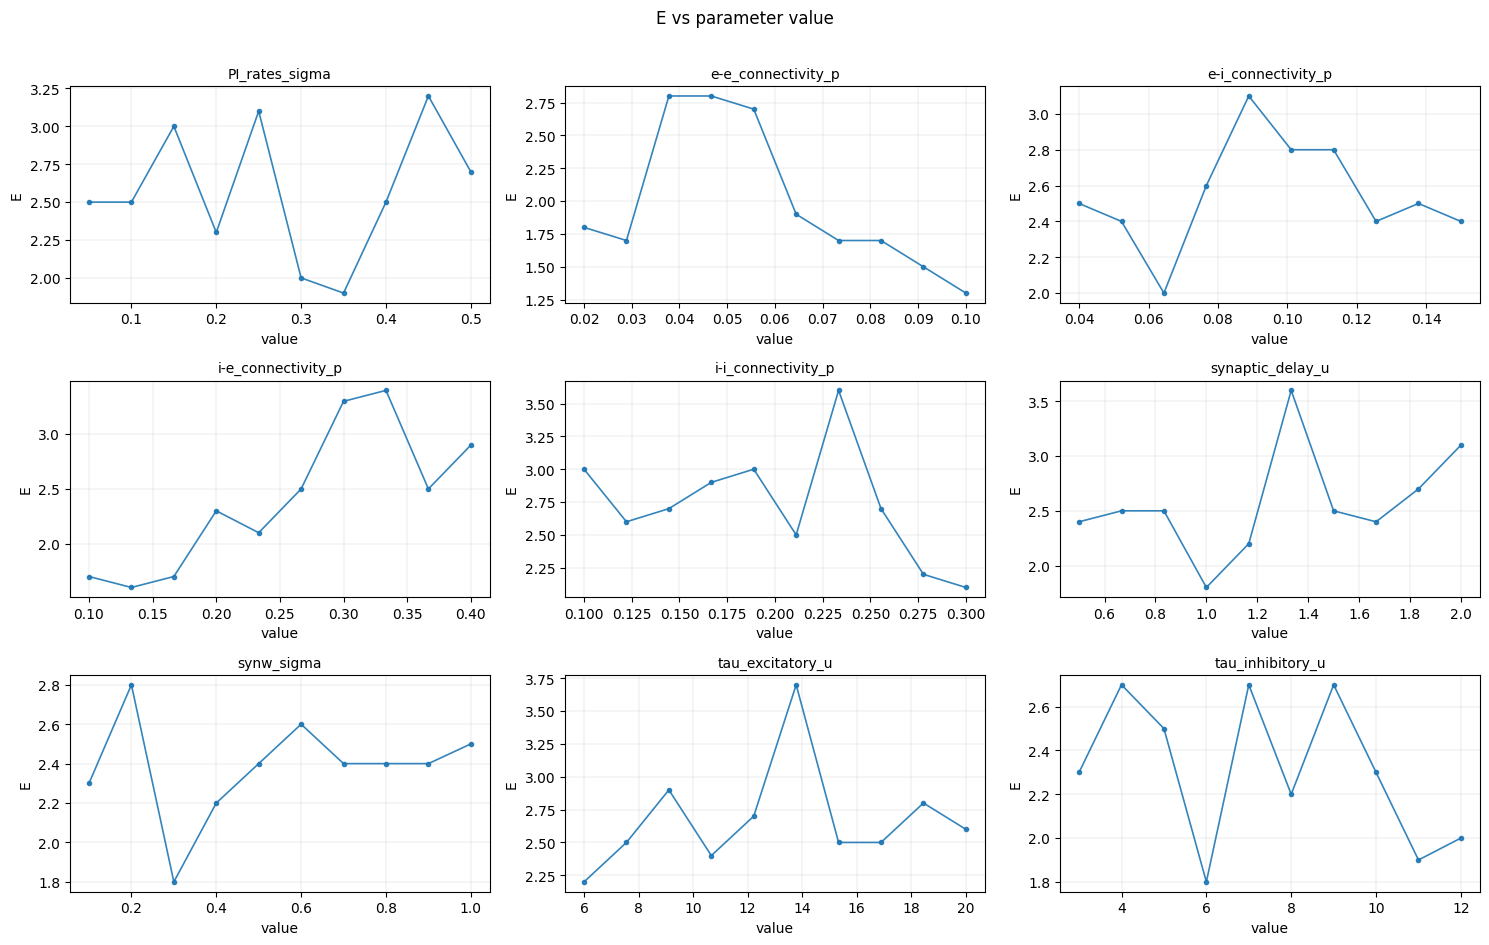

                        PR                            E                 
                      mean     std    min     max  mean    std  min  max
param                                                                   
PI_rates_sigma       2.516   0.106  2.419   2.774  2.57  0.440  1.9  3.2
e-e_connectivity_p  12.577  20.042  1.025  57.270  1.99  0.561  1.3  2.8
e-i_connectivity_p  10.489  10.634  1.328  30.081  2.55  0.299  2.0  3.1
i-e_connectivity_p   3.701   3.021  1.025   9.044  2.40  0.650  1.6  3.4
i-i_connectivity_p   2.477   0.788  1.429   3.591  2.73  0.432  2.1  3.6
synaptic_delay_u     2.462   0.289  2.135   3.138  2.57  0.490  1.8  3.6
synw_sigma           2.674   0.169  2.508   3.053  2.38  0.262  1.8  2.8
tau_excitatory_u     4.196   1.822  2.503   7.768  2.68  0.410  2.2  3.7
tau_inhibitory_u     5.631   4.389  1.384  13.336  2.31  0.338  1.8  2.7


In [4]:
#Relationship between PR and E

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Load data =====
CSV_PATH = "E_PR_grid_results.csv"  # change if needed
df = pd.read_csv(CSV_PATH)

# Basic checks
needed = {'param', 'value', 'PR', 'E'}
missing = needed - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing columns: {missing}")

df = df.dropna(subset=['PR', 'E']).copy()
print(f"Loaded {len(df)} rows after cleaning.\n")

# ===== 1) Global scatter =====
plt.figure(figsize=(6, 5))
plt.scatter(df['PR'], df['E'], s=18, alpha=0.7)
plt.xlabel("Participation Ratio (PR)")
plt.ylabel("Embedding Dimension (E)")
plt.title("Global relationship: PR vs E")
plt.grid(True, linewidth=0.3, alpha=0.6)
plt.show()

# ===== 2) Helper for parameter panels =====
def panel_plot(df_in, y_col, title):
    params = sorted(df_in['param'].unique())
    ncols = 3
    nrows = math.ceil(len(params) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), squeeze=False)
    axes = axes.ravel()
    for i, p in enumerate(params):
        ax = axes[i]
        sub = df_in[df_in['param'] == p].copy().sort_values('value')
        ax.plot(sub['value'], sub[y_col], marker='o', markersize=3, linewidth=1.2, alpha=0.9)
        ax.set_title(p, fontsize=10)
        ax.set_xlabel("value")
        ax.set_ylabel(y_col)
        ax.grid(True, linewidth=0.3, alpha=0.6)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# ===== 3) Plot PR and E by parameter =====
panel_plot(df, y_col="PR", title="PR vs parameter value")
panel_plot(df, y_col="E", title="E vs parameter value")

# ===== 4) Summary table =====
summary = (df.groupby('param')[['PR','E']]
             .agg(['mean','std','min','max'])
             .round(3))
print(summary)


Loaded 230 rows after cleaning.



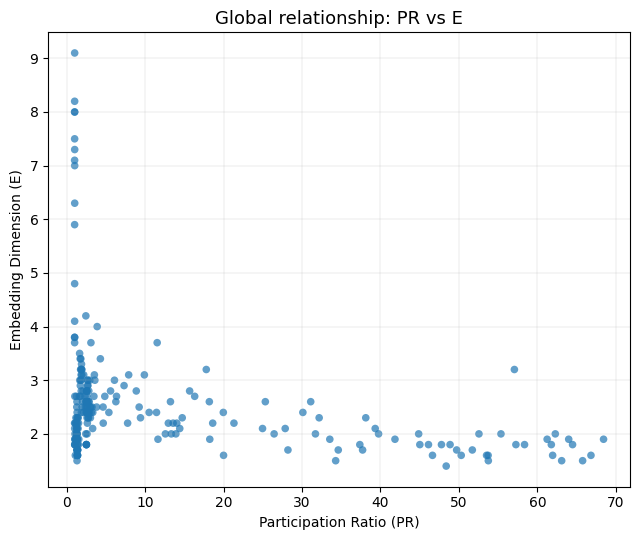

Global correlation between PR and E: r = -0.304, p = 2.588e-06



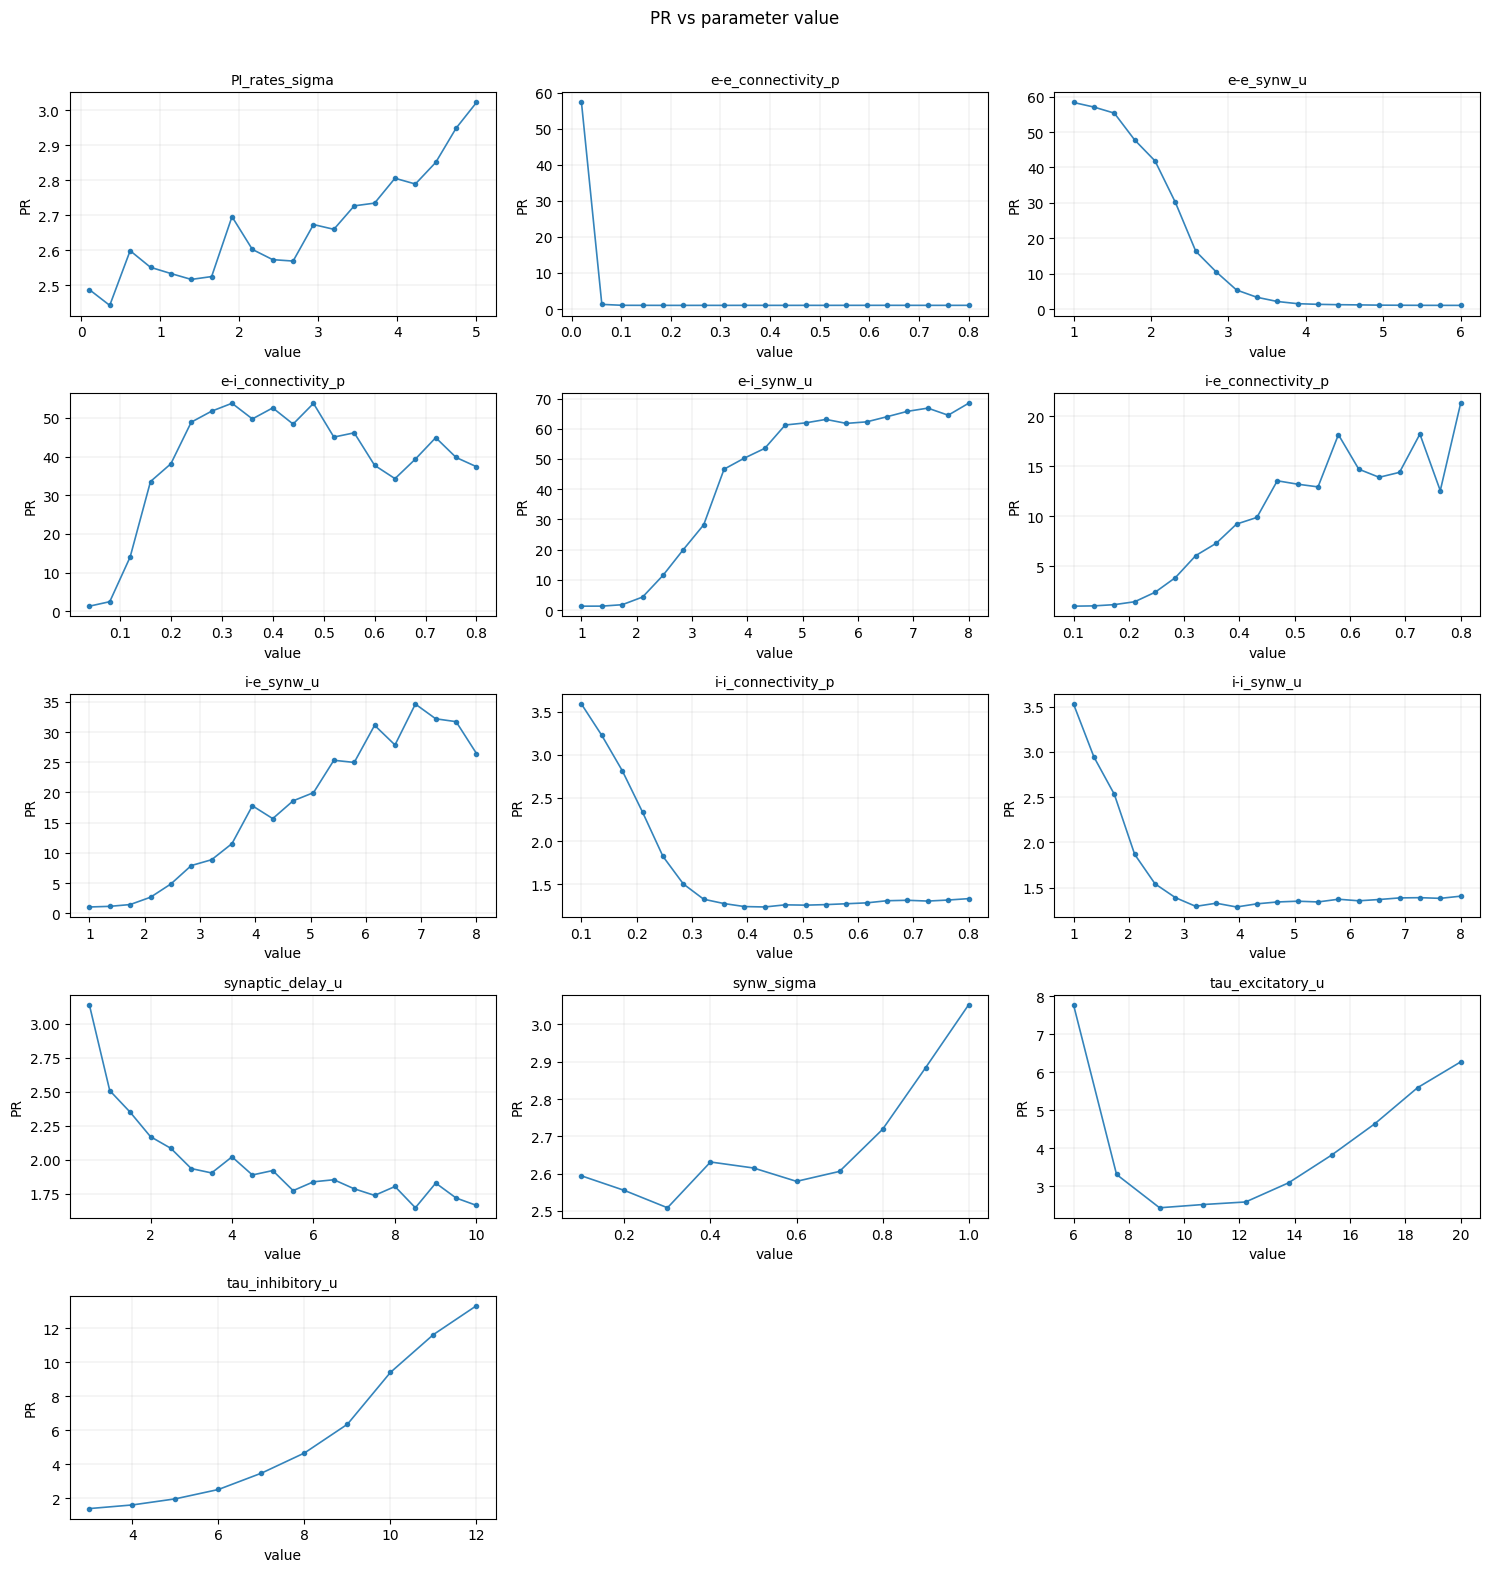

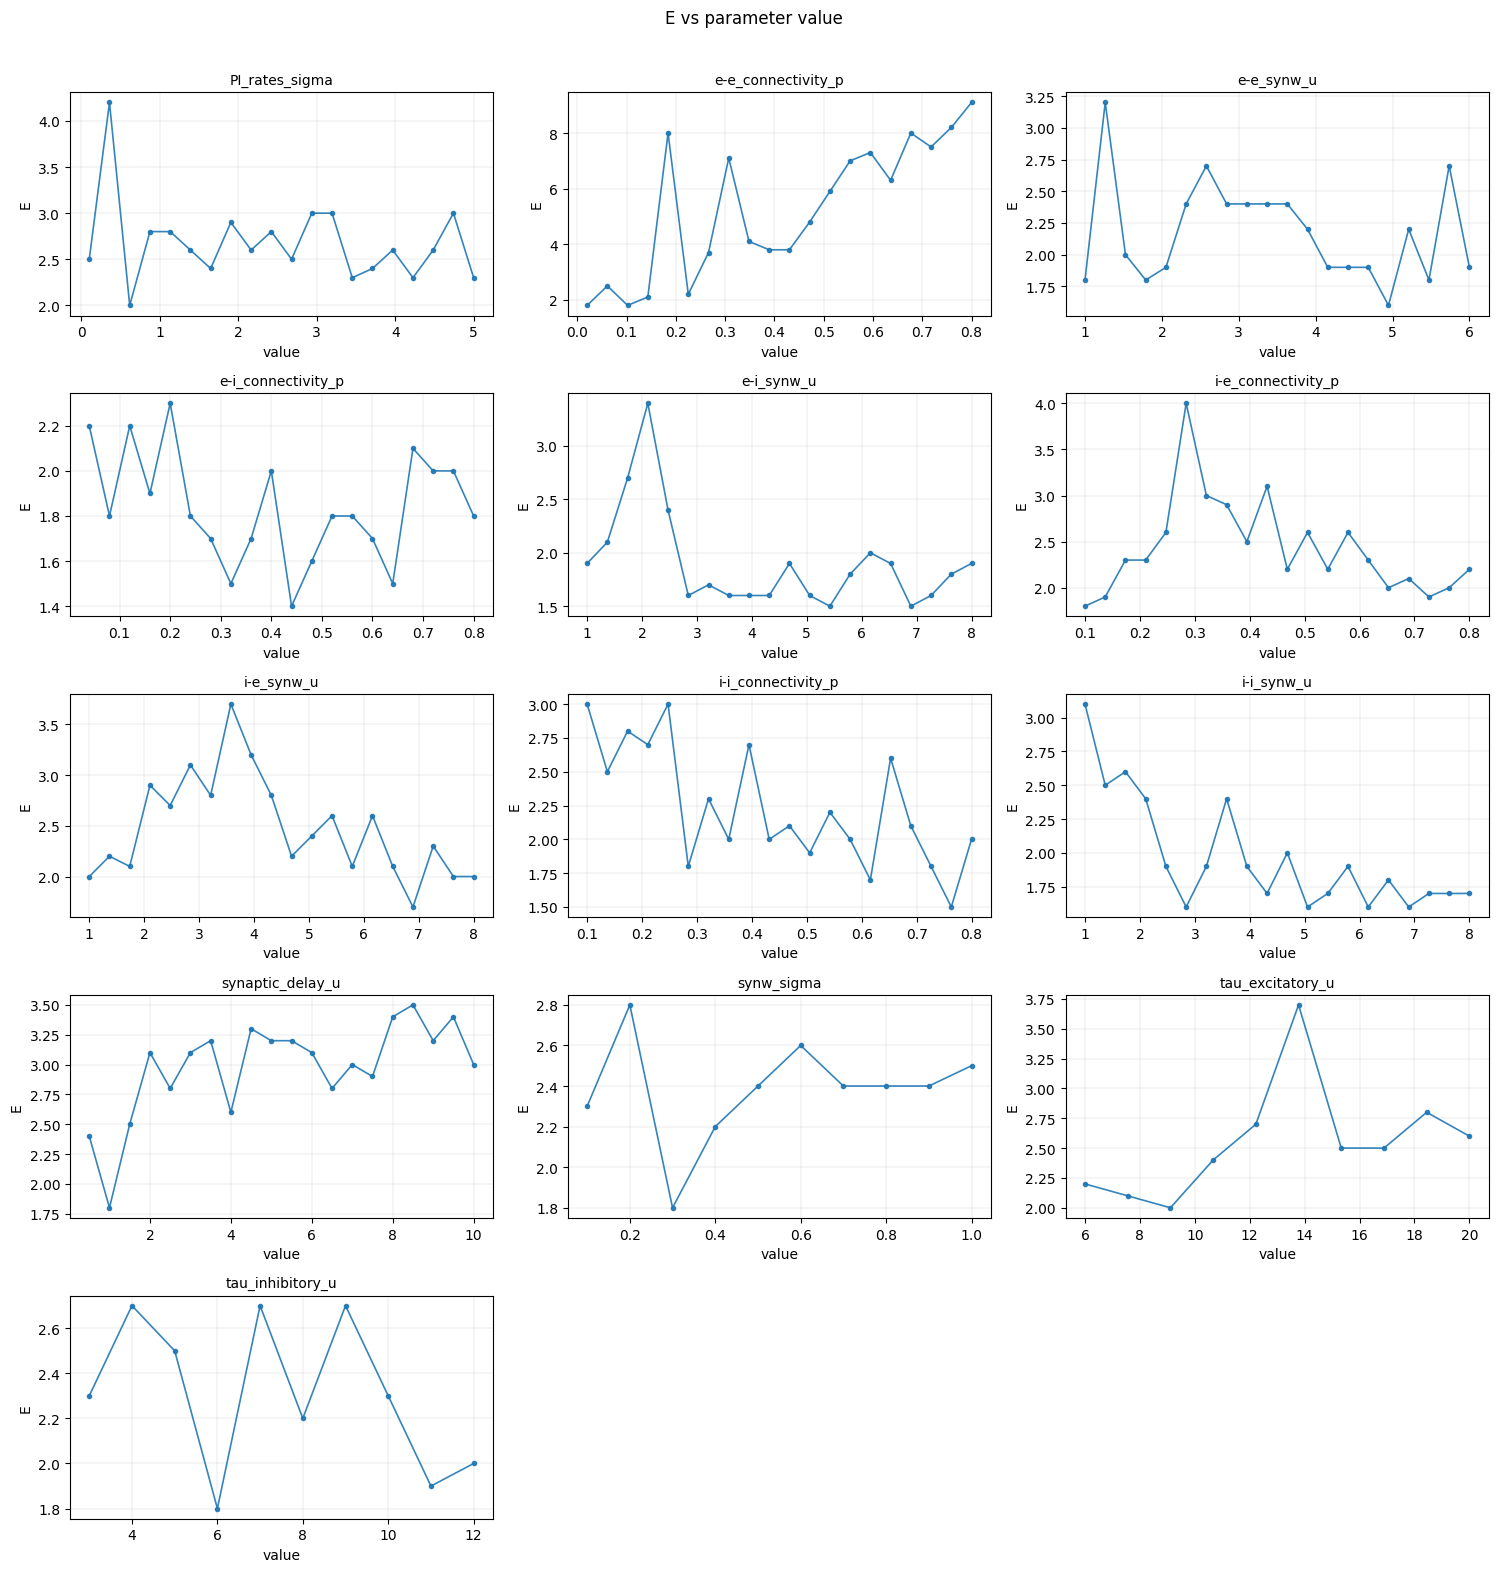

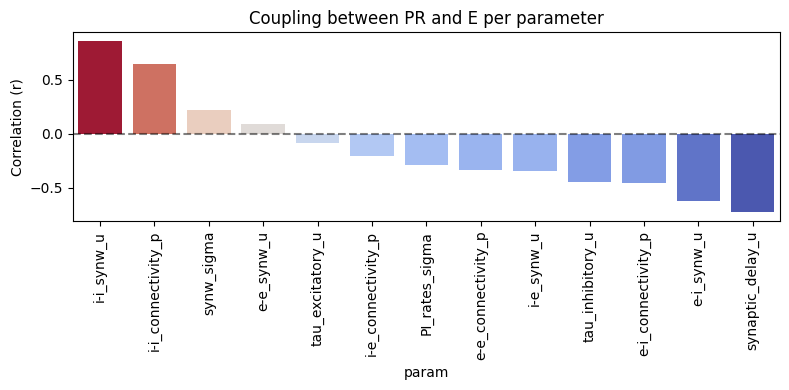

Per-parameter correlation between PR and E:
             param      r     p
        i-i_synw_u  0.859 0.000
i-i_connectivity_p  0.644 0.002
        synw_sigma  0.220 0.542
        e-e_synw_u  0.095 0.691
  tau_excitatory_u -0.088 0.808
i-e_connectivity_p -0.207 0.380
    PI_rates_sigma -0.285 0.224
e-e_connectivity_p -0.332 0.153
        i-e_synw_u -0.348 0.133
  tau_inhibitory_u -0.448 0.195
e-i_connectivity_p -0.456 0.043
        e-i_synw_u -0.621 0.003
  synaptic_delay_u -0.728 0.000

Summary statistics (PR and E by parameter):

                        PR                             E                 
                      mean     std    min     max   mean    std  min  max
param                                                                    
PI_rates_sigma       2.666   0.157  2.443   3.023  2.680  0.450  2.0  4.2
e-e_connectivity_p   3.841  12.576  1.007  57.270  5.250  2.456  1.8  9.1
e-e_synw_u          16.937  22.205  1.033  58.372  2.175  0.399  1.6  3.2
e-i_connectivity_p

In [5]:
# ===============================================================
# Relationship between Participation Ratio (PR) and Embedding Dimension (E)
# ===============================================================
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ===== Load data =====
CSV_PATH = "E_PR_grid_results.csv"  # change if needed
df = pd.read_csv(CSV_PATH)

# Basic checks
needed = {'param', 'value', 'PR', 'E'}
missing = needed - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing columns: {missing}")

df = df.dropna(subset=['PR', 'E']).copy()
print(f"Loaded {len(df)} rows after cleaning.\n")

# ===============================================================
# 1) GLOBAL RELATIONSHIP: PR vs E
# ===============================================================
plt.figure(figsize=(6.5, 5.5))
sns.scatterplot(data=df, x='PR', y='E', s=30, alpha=0.7, edgecolor='none')
plt.xlabel("Participation Ratio (PR)")
plt.ylabel("Embedding Dimension (E)")
plt.title("Global relationship: PR vs E", fontsize=13)
plt.grid(True, linewidth=0.3, alpha=0.6)
plt.tight_layout()
plt.show()

# Global correlation
r_global, p_global = pearsonr(df['PR'], df['E'])
print(f"Global correlation between PR and E: r = {r_global:.3f}, p = {p_global:.3e}\n")

# ===============================================================
# 2) Helper for parameter panel plots
# ===============================================================
def panel_plot(df_in, y_col, title):
    params = sorted(df_in['param'].unique())
    ncols = 3
    nrows = math.ceil(len(params) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), squeeze=False)
    axes = axes.ravel()

    for i, p in enumerate(params):
        ax = axes[i]
        sub = df_in[df_in['param'] == p].copy().sort_values('value')
        ax.plot(sub['value'], sub[y_col], marker='o', markersize=3, linewidth=1.2, alpha=0.9)
        ax.set_title(p, fontsize=10)
        ax.set_xlabel("value")
        ax.set_ylabel(y_col)
        ax.grid(True, linewidth=0.3, alpha=0.6)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# ===============================================================
# 3) PR and E vs parameter value
# ===============================================================
panel_plot(df, y_col="PR", title="PR vs parameter value")
panel_plot(df, y_col="E", title="E vs parameter value")

# ===============================================================
# 4) Per-parameter PR–E correlation + significance
# ===============================================================
corr_list = []
for p in df['param'].unique():
    sub = df[df['param'] == p]
    if len(sub) > 2:
        r, pval = pearsonr(sub['PR'], sub['E'])
        corr_list.append({'param': p, 'r': r, 'p': pval})
corr_df = pd.DataFrame(corr_list).sort_values('r', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=corr_df, x='param', y='r',
    palette='coolwarm', hue='r', dodge=False
)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xticks(rotation=90)
plt.ylabel("Correlation (r)")
plt.title("Coupling between PR and E per parameter")
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

print("Per-parameter correlation between PR and E:")
print(corr_df.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# ===============================================================
# 5) Summary table
# ===============================================================
summary = (
    df.groupby('param')[['PR', 'E']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(3)
)
print("\nSummary statistics (PR and E by parameter):\n")
print(summary)


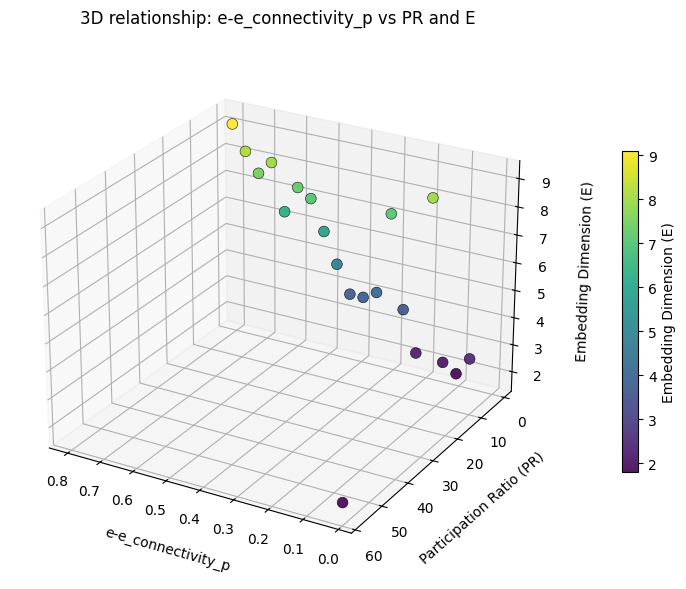

In [6]:
# ===============================================================
# 6) 3D Visualization: e-e_connectivity_p vs E and PR
# ===============================================================
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

param_of_interest = 'e-e_connectivity_p'
sub = df[df['param'] == param_of_interest].copy().sort_values('value')

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
p = ax.scatter(
    sub['value'], sub['PR'], sub['E'],
    c=sub['E'], cmap='viridis', s=60, alpha=0.9, edgecolor='k', linewidth=0.4
)

# Labels
ax.set_xlabel(f"{param_of_interest}", labelpad=10)
ax.set_ylabel("Participation Ratio (PR)", labelpad=10)
ax.set_zlabel("Embedding Dimension (E)", labelpad=10)
ax.set_title(f"3D relationship: {param_of_interest} vs PR and E", pad=15)

# Colorbar
cbar = fig.colorbar(p, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Embedding Dimension (E)")

# Aesthetic tweaks
ax.grid(True, linewidth=0.3, alpha=0.5)
ax.view_init(elev=25, azim=120)  # adjust view angle as you like

plt.tight_layout()
plt.show()


In [27]:
df = pd.read_csv('E_PR_2D_grid.csv')
df

,e-e_connectivity_p,e-e_synw_u,PR,E
0,0.02,1.000000,60.151610,2.6
1,0.02,1.333333,59.940161,1.5
2,0.02,1.666667,58.827036,1.8
3,0.02,2.000000,58.468908,1.6
4,0.02,2.333333,58.499998,1.8
...,...,...,...,...
95,0.80,2.666667,1.015640,6.7
96,0.80,3.000000,1.015247,5.8
97,0.80,3.333333,1.017859,8.0
98,0.80,3.666667,1.016609,7.9


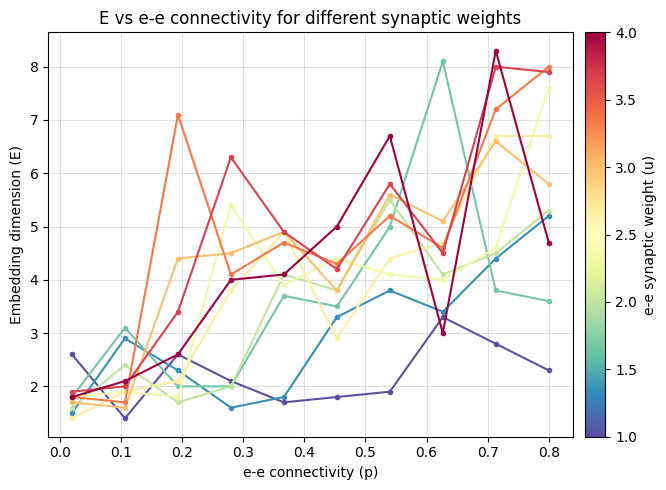

In [31]:
# ===============================================================
# Plot: E vs e-e_connectivity_p (colored by e-e_synw_u)
# ===============================================================
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_plot = df.dropna(subset=['E']).copy()

# Sort for clean line plotting
df_plot = df_plot.sort_values(['e-e_synw_u', 'e-e_connectivity_p'])

fig, ax = plt.subplots(figsize=(7, 5))
palette = sns.color_palette("Spectral_r", as_cmap=True)

for w in sorted(df_plot['e-e_synw_u'].unique()):
    sub = df_plot[df_plot['e-e_synw_u'] == w]
    ax.plot(sub['e-e_connectivity_p'], sub['E'], marker='o', markersize=3,
            label=f"{w:.2f}", color=palette((w - df_plot['e-e_synw_u'].min()) /
                                            (df_plot['e-e_synw_u'].max() - df_plot['e-e_synw_u'].min())))

sm = plt.cm.ScalarMappable(cmap='Spectral_r',
                           norm=plt.Normalize(vmin=df_plot['e-e_synw_u'].min(),
                                              vmax=df_plot['e-e_synw_u'].max()))
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("e-e synaptic weight (u)")

ax.set_xlabel("e-e connectivity (p)")
ax.set_ylabel("Embedding dimension (E)")
ax.set_title("E vs e-e connectivity for different synaptic weights")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


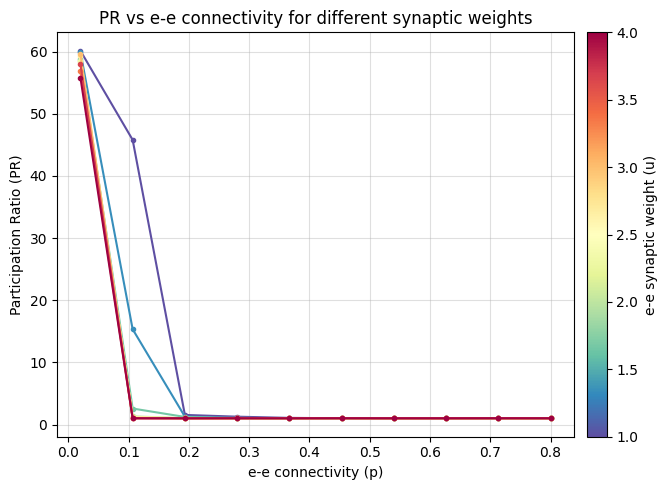

In [34]:
# ===============================================================
# Plot: PR vs e-e_connectivity_p (colored by e-e_synw_u)
# ===============================================================
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_plot = df.dropna(subset=['PR']).copy()
df_plot = df_plot.sort_values(['e-e_synw_u', 'e-e_connectivity_p'])

fig, ax = plt.subplots(figsize=(7, 5))
palette = sns.color_palette("Spectral_r", as_cmap=True)

w_min = df_plot['e-e_synw_u'].min()
w_max = df_plot['e-e_synw_u'].max()
denom = (w_max - w_min) if (w_max > w_min) else 1.0

for w in sorted(df_plot['e-e_synw_u'].unique()):
    sub = df_plot[df_plot['e-e_synw_u'] == w]
    color = palette((w - w_min) / denom)
    ax.plot(sub['e-e_connectivity_p'], sub['PR'], marker='o', markersize=3,
            label=f"{w:.2f}", color=color)

# Colorbar keyed to synaptic weight
sm = plt.cm.ScalarMappable(cmap='Spectral_r',
                           norm=plt.Normalize(vmin=w_min, vmax=w_max))
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("e-e synaptic weight (u)")
ax.set_xlabel("e-e connectivity (p)")
ax.set_ylabel("Participation Ratio (PR)")
ax.set_title("PR vs e-e connectivity for different synaptic weights")
ax.grid(True, alpha=0.4)
#plt.xscale('log')
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import pearsonr

# Load the results
CSV_PATH = "E_PR_2D_grid_wide.csv"
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=['PR','E'])
print(f"{len(df)} valid rows\n")
print(df.head())


600 valid rows

   e-e_connectivity_p  e-e_synw_u         PR    E
0                0.02    0.100000  61.012716  1.6
1                0.02    0.372414  60.443416  1.3
2                0.02    0.644828  60.734826  3.0
3                0.02    0.917241  59.274290  1.4
4                0.02    1.189655  60.590475  2.0


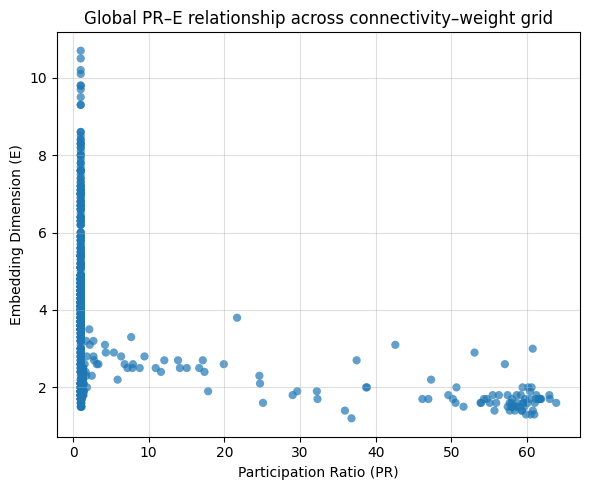

Global correlation: r = -0.398, p = 3.525e-24


In [4]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='PR', y='E', s=35, alpha=0.7, edgecolor='none')
plt.xlabel("Participation Ratio (PR)")
plt.ylabel("Embedding Dimension (E)")
plt.title("Global PR–E relationship across connectivity–weight grid")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

r, p = pearsonr(df['PR'], df['E'])
print(f"Global correlation: r = {r:.3f}, p = {p:.3e}")


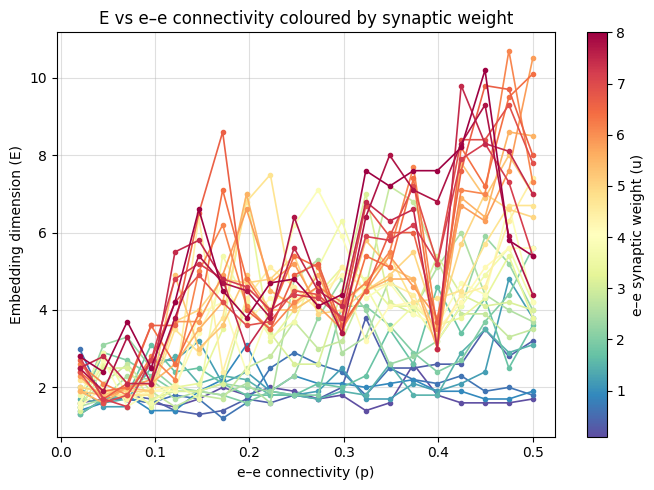

In [5]:
dfE = df.sort_values(['e-e_synw_u','e-e_connectivity_p'])
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.Spectral_r
for w in sorted(dfE['e-e_synw_u'].unique()):
    sub = dfE[dfE['e-e_synw_u']==w]
    c = cmap((w - dfE['e-e_synw_u'].min()) / (dfE['e-e_synw_u'].max() - dfE['e-e_synw_u'].min()))
    ax.plot(sub['e-e_connectivity_p'], sub['E'], marker='o', ms=3, lw=1.2, color=c)
sm = plt.cm.ScalarMappable(cmap=cmap, 
                           norm=plt.Normalize(dfE['e-e_synw_u'].min(), dfE['e-e_synw_u'].max()))
plt.colorbar(sm, ax=ax, label="e–e synaptic weight (u)")
ax.set_xlabel("e–e connectivity (p)")
ax.set_ylabel("Embedding dimension (E)")
ax.set_title("E vs e–e connectivity coloured by synaptic weight")
ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()


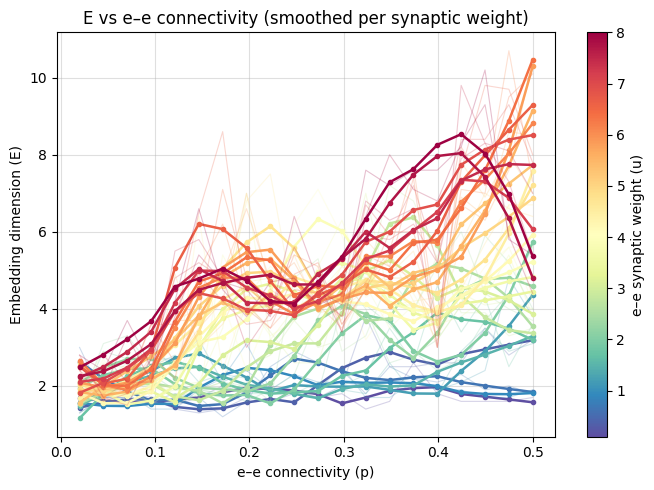

In [7]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

dfE = df.dropna(subset=['E']).sort_values(['e-e_synw_u','e-e_connectivity_p']).copy()

def smooth_savgol(y, frac=0.35, poly=2):
    n = len(y)
    win = max(5, int(np.ceil(frac*n)) | 1)  # odd window >=5
    win = min(win, n if n%2==1 else n-1)    # cannot exceed series length
    if win < 5:  # too short to smooth
        return y
    return savgol_filter(y, window_length=win, polyorder=min(poly, win-1))

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.Spectral_r

w_min, w_max = dfE['e-e_synw_u'].min(), dfE['e-e_synw_u'].max()
for w in sorted(dfE['e-e_synw_u'].unique()):
    sub = dfE[dfE['e-e_synw_u']==w]
    x = sub['e-e_connectivity_p'].to_numpy()
    y = sub['E'].to_numpy()
    y_sm = smooth_savgol(y, frac=0.35, poly=2)

    c = cmap((w - w_min)/(w_max - w_min + 1e-9))
    # (optional) faint raw curve
    ax.plot(x, y, color=c, alpha=0.25, lw=0.8)
    # smoothed curve
    ax.plot(x, y_sm, marker='o', ms=3, lw=1.8, color=c)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=w_min, vmax=w_max))
plt.colorbar(sm, ax=ax, label="e–e synaptic weight (u)")
ax.set_xlabel("e–e connectivity (p)")
ax.set_ylabel("Embedding dimension (E)")
ax.set_title("E vs e–e connectivity (smoothed per synaptic weight)")
ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()


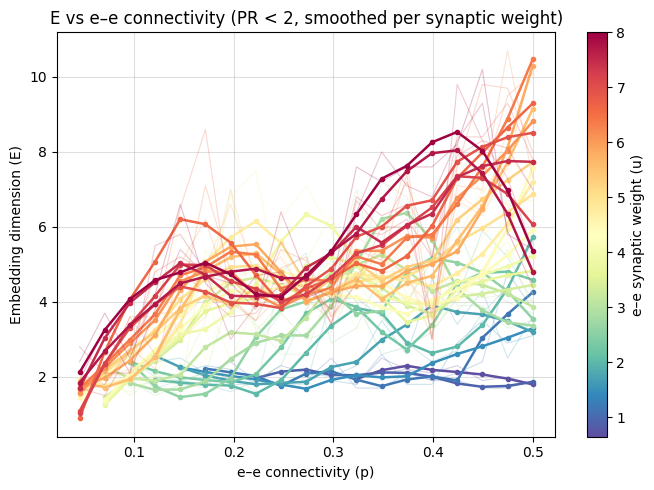

In [20]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# Filter to PR < 2 and sort
dfE = (
    df.dropna(subset=['E','PR'])
      .query('PR <  1.5')
      .sort_values(['e-e_synw_u','e-e_connectivity_p'])
      .copy()
)

if dfE.empty:
    print("No rows with PR < 2 — nothing to plot.")
else:
    def smooth_savgol(y, frac=0.35, poly=2):
        n = len(y)
        win = max(5, int(np.ceil(frac*n)) | 1)    # odd window >=5
        win = min(win, n if n % 2 == 1 else n-1)  # cannot exceed series length
        if win < 5:  # too short to smooth
            return y
        return savgol_filter(y, window_length=win, polyorder=min(poly, win-1))

    fig, ax = plt.subplots(figsize=(7,5))
    cmap = plt.cm.Spectral_r

    w_min, w_max = dfE['e-e_synw_u'].min(), dfE['e-e_synw_u'].max()
    for w in sorted(dfE['e-e_synw_u'].unique()):
        sub = dfE[dfE['e-e_synw_u'] == w]
        x = sub['e-e_connectivity_p'].to_numpy()
        y = sub['E'].to_numpy()
        y_sm = smooth_savgol(y, frac=0.35, poly=2)

        c = cmap((w - w_min) / (w_max - w_min + 1e-9))
        # optional faint raw curve
        ax.plot(x, y, color=c, alpha=0.25, lw=0.8)
        # smoothed curve
        ax.plot(x, y_sm, marker='o', ms=3, lw=1.8, color=c, label=None)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=w_min, vmax=w_max))
    plt.colorbar(sm, ax=ax, label="e–e synaptic weight (u)")
    ax.set_xlabel("e–e connectivity (p)")
    ax.set_ylabel("Embedding dimension (E)")
    ax.set_title("E vs e–e connectivity (PR < 2, smoothed per synaptic weight)")
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

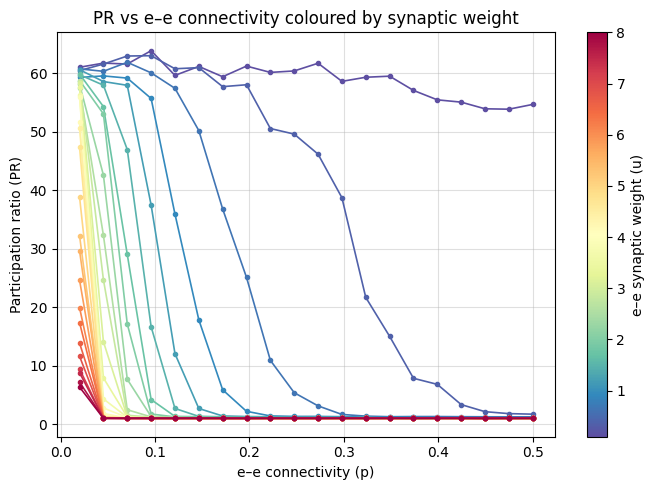

In [6]:
dfP = df.sort_values(['e-e_synw_u','e-e_connectivity_p'])
fig, ax = plt.subplots(figsize=(7,5))
for w in sorted(dfP['e-e_synw_u'].unique()):
    sub = dfP[dfP['e-e_synw_u']==w]
    c = cmap((w - dfP['e-e_synw_u'].min()) / (dfP['e-e_synw_u'].max() - dfP['e-e_synw_u'].min()))
    ax.plot(sub['e-e_connectivity_p'], sub['PR'], marker='o', ms=3, lw=1.2, color=c)
sm = plt.cm.ScalarMappable(cmap=cmap, 
                           norm=plt.Normalize(dfP['e-e_synw_u'].min(), dfP['e-e_synw_u'].max()))
plt.colorbar(sm, ax=ax, label="e–e synaptic weight (u)")
ax.set_xlabel("e–e connectivity (p)")
ax.set_ylabel("Participation ratio (PR)")
ax.set_title("PR vs e–e connectivity coloured by synaptic weight")
ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

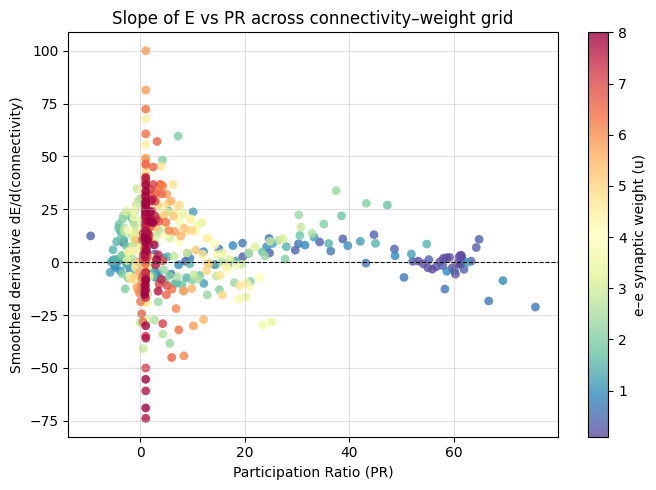

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

# Sort and copy
dfS = df.dropna(subset=['E','PR']).sort_values(['e-e_synw_u','e-e_connectivity_p']).copy()

# Parameters for smoothing
smooth_frac = 0.4
poly = 3

def smooth_and_derivative(x, y, frac=smooth_frac, poly=poly):
    """Smooth y(x) and compute derivative dy/dx."""
    n = len(y)
    if n < 5:
        return y, np.gradient(y, x)
    win = max(5, int(frac * n) | 1)
    win = min(win, n if n % 2 == 1 else n - 1)
    y_smooth = savgol_filter(y, window_length=win, polyorder=min(poly, win - 1))
    dy_dp = np.gradient(y_smooth, x)
    return y_smooth, dy_dp

# Collect smoothed (PR, dE/dp) pairs
rows = []
for w in sorted(dfS['e-e_synw_u'].unique()):
    sub = dfS[dfS['e-e_synw_u']==w]
    x = sub['e-e_connectivity_p'].to_numpy()
    E = sub['E'].to_numpy()
    PR = sub['PR'].to_numpy()

    # Smooth both curves
    E_smooth, dE_dp = smooth_and_derivative(x, E)
    PR_smooth = savgol_filter(PR, window_length=min(len(PR)//2*2-1, len(PR)), polyorder=2) if len(PR) >= 5 else PR

    for p_val, pr_val, slope in zip(x, PR_smooth, dE_dp):
        rows.append({'e-e_synw_u': w, 'connectivity': p_val, 'PR': pr_val, 'dE_dp': slope})

df_deriv = pd.DataFrame(rows).dropna()

# --- Scatter plot of dE/dp vs PR ---
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.Spectral_r
sc = ax.scatter(df_deriv['PR'], df_deriv['dE_dp'],
                c=df_deriv['e-e_synw_u'], cmap=cmap,
                s=40, alpha=0.8, edgecolor='none')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("e–e synaptic weight (u)")

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel("Participation Ratio (PR)")
ax.set_ylabel("Smoothed derivative dE/d(connectivity)")
ax.set_title("Slope of E vs PR across connectivity–weight grid")
ax.grid(alpha=0.4)
plt.tight_layout()
#plt.xscale('log')
plt.show()

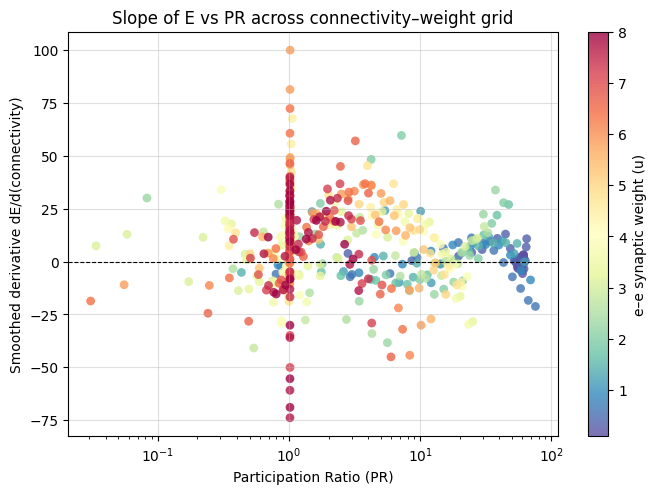

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

# Sort and copy
dfS = df.dropna(subset=['E','PR']).sort_values(['e-e_synw_u','e-e_connectivity_p']).copy()

# Parameters for smoothing
smooth_frac = 0.4
poly = 3

def smooth_and_derivative(x, y, frac=smooth_frac, poly=poly):
    """Smooth y(x) and compute derivative dy/dx."""
    n = len(y)
    if n < 5:
        return y, np.gradient(y, x)
    win = max(5, int(frac * n) | 1)
    win = min(win, n if n % 2 == 1 else n - 1)
    y_smooth = savgol_filter(y, window_length=win, polyorder=min(poly, win - 1))
    dy_dp = np.gradient(y_smooth, x)
    return y_smooth, dy_dp

# Collect smoothed (PR, dE/dp) pairs
rows = []
for w in sorted(dfS['e-e_synw_u'].unique()):
    sub = dfS[dfS['e-e_synw_u']==w]
    x = sub['e-e_connectivity_p'].to_numpy()
    E = sub['E'].to_numpy()
    PR = sub['PR'].to_numpy()

    # Smooth both curves
    E_smooth, dE_dp = smooth_and_derivative(x, E)
    PR_smooth = savgol_filter(PR, window_length=min(len(PR)//2*2-1, len(PR)), polyorder=2) if len(PR) >= 5 else PR

    for p_val, pr_val, slope in zip(x, PR_smooth, dE_dp):
        rows.append({'e-e_synw_u': w, 'connectivity': p_val, 'PR': pr_val, 'dE_dp': slope})

df_deriv = pd.DataFrame(rows).dropna()

# --- Scatter plot of dE/dp vs PR ---
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.Spectral_r
sc = ax.scatter(df_deriv['PR'], df_deriv['dE_dp'],
                c=df_deriv['e-e_synw_u'], cmap=cmap,
                s=40, alpha=0.8, edgecolor='none')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("e–e synaptic weight (u)")

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel("Participation Ratio (PR)")
ax.set_ylabel("Smoothed derivative dE/d(connectivity)")
ax.set_title("Slope of E vs PR across connectivity–weight grid")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.xscale('log')
plt.show()

In [ ]:
#explore 2 regimes
# Weakly Coupled, Recurrent regime
# Strongly Coupled, Recurrent regime

In [24]:
from pyEDM import EmbedDimension
def E_from_pcs(PCs, maxE=20, Tp=1, tau=10, lib_frac=0.6):
    PCs = np.asarray(PCs)
    T, K = PCs.shape
    df = pd.DataFrame(PCs, columns=[f"PC{i+1}" for i in range(K)])
    df.insert(0, "Time", np.arange(T))
    split = int(lib_frac * T)
    lib, pred = f"1 {split}", f"{split+1} {T}"
    E_per_pc, rho_per_pc = np.full(K, np.nan), np.full(K, np.nan)
    for k in range(K):
        target = f"PC{k+1}"
        out = EmbedDimension(dataFrame=df, columns=target, target=target,
                             maxE=maxE, lib=lib, pred=pred, Tp=Tp, tau=tau,
                             embedded=False, numProcess=1, showPlot=False)
        best = out.loc[out['rho'].idxmax()]
        E_per_pc[k], rho_per_pc[k] = best['E'], best['rho']
    return np.mean(E_per_pc), np.mean(rho_per_pc)
    
base_pars = {
    'spike_threshold_u': -50,
    'spike_threshold_sigma': 5,
    'rmp_u': -70,
    'rmp_sigma': 1,
    'synaptic_delay_u': 1.0,
    'synaptic_delay_sigma': 0.15,
    'tau_excitatory_u': 12,
    'tau_inhibitory_u': 6,
    'tau_sigma': 2,
    'refractory_excitatory_u': 2.0,
    'refractory_inhibitory_u': 1.0,
    'refractory_sigma': 0.5,
    'excitatory_size': 1000,
    'inhibitory_size': 400,
    'e-e_connectivity_p': 0.05,
    'e-i_connectivity_p': 0.08,
    'i-e_connectivity_p': 0.25,
    'i-i_connectivity_p': 0.20,
    'e-e_synw_u': 3.5,
    'e-i_synw_u': 1.9,
    'i-e_synw_u': 2.1,
    'i-i_synw_u': 1.7,
    'synw_sigma': 0.3,
    'PI_size': 1000,
    'PI_p': 0.1,
    'PI_rates_u_excitatory': 8,
    'PI_rates_u_inhibitory': 8,
    'PI_rates_sigma': 0.1,
    'PI_weights_sigma': 0.2,
    'PI_weights_u_excitatory': 1.0,
    'PI_weights_u_inhibitory': 1.0
}

In [29]:
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler

#Low E, Low PR
#1: synw-6, eep-> 0.1
_pars = base_pars.copy()
_pars.update({'e-e_synw_u':6,
              'e-e_connectivity_p': 0.1})

E_mat, I_mat = _run(_pars)
comb = np.array(sp.vstack((E_mat,I_mat)).todense())
dt_native = 1/100.0
mat = np.array(sp.vstack((E_mat, I_mat)).todense())
fmat = spk_to_fl(S=mat, dt_native=1/100)
PR, _ = participation_ratio(fmat)
X = fmat.T[200:]
sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=10).fit_transform(sc)
E_mean, _ = E_from_pcs(pca)

In [47]:
print(E_mean, PR)

3.0 1.0100817268553248


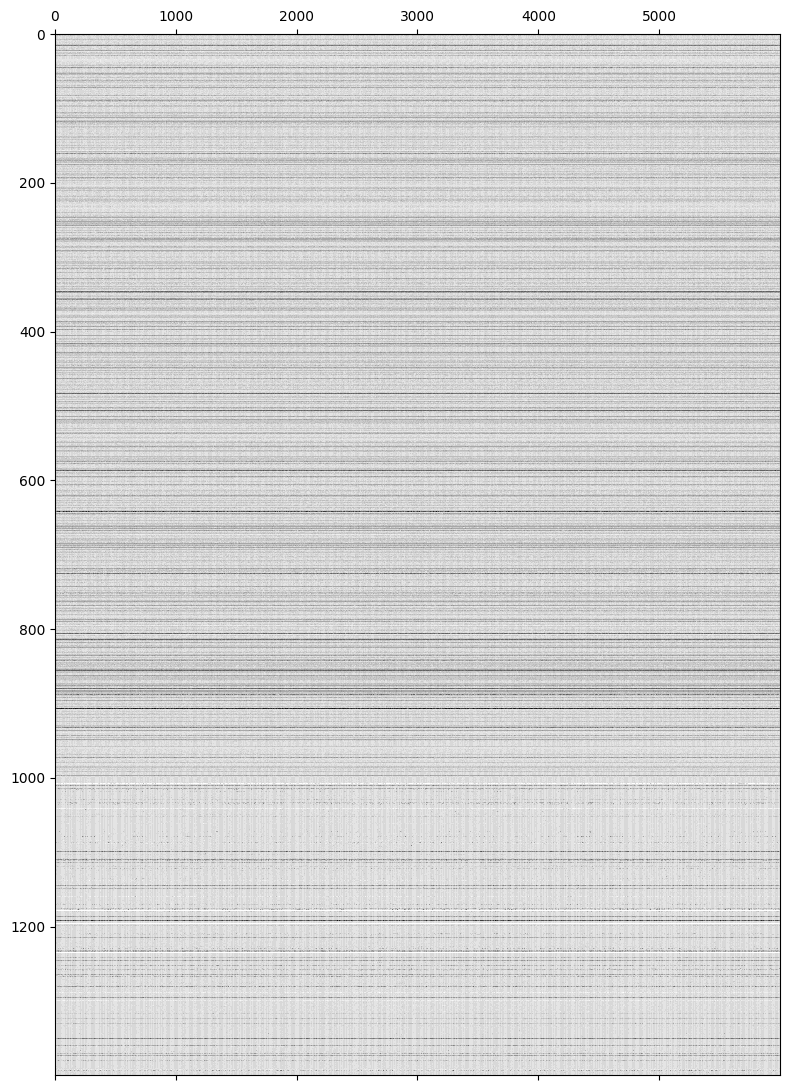

In [46]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(comb, cmap='Greys', aspect='auto')
plt.tight_layout()
plt.show()

In [48]:
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler

#Low E, Low PR
#2: synw-1.5, eep->0.2
_pars = base_pars.copy()
_pars.update({'e-e_synw_u':1.5,
              'e-e_connectivity_p': 0.2})

E_mat, I_mat = _run(_pars)
comb = np.array(sp.vstack((E_mat,I_mat)).todense())
dt_native = 1/100.0
mat = np.array(sp.vstack((E_mat, I_mat)).todense())
fmat = spk_to_fl(S=mat, dt_native=1/100)
PR, _ = participation_ratio(fmat)
X = fmat.T[200:]
sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=10).fit_transform(sc)
E_mean, _ = E_from_pcs(pca)
print(E_mean, PR)

1.8 1.2525359657732662


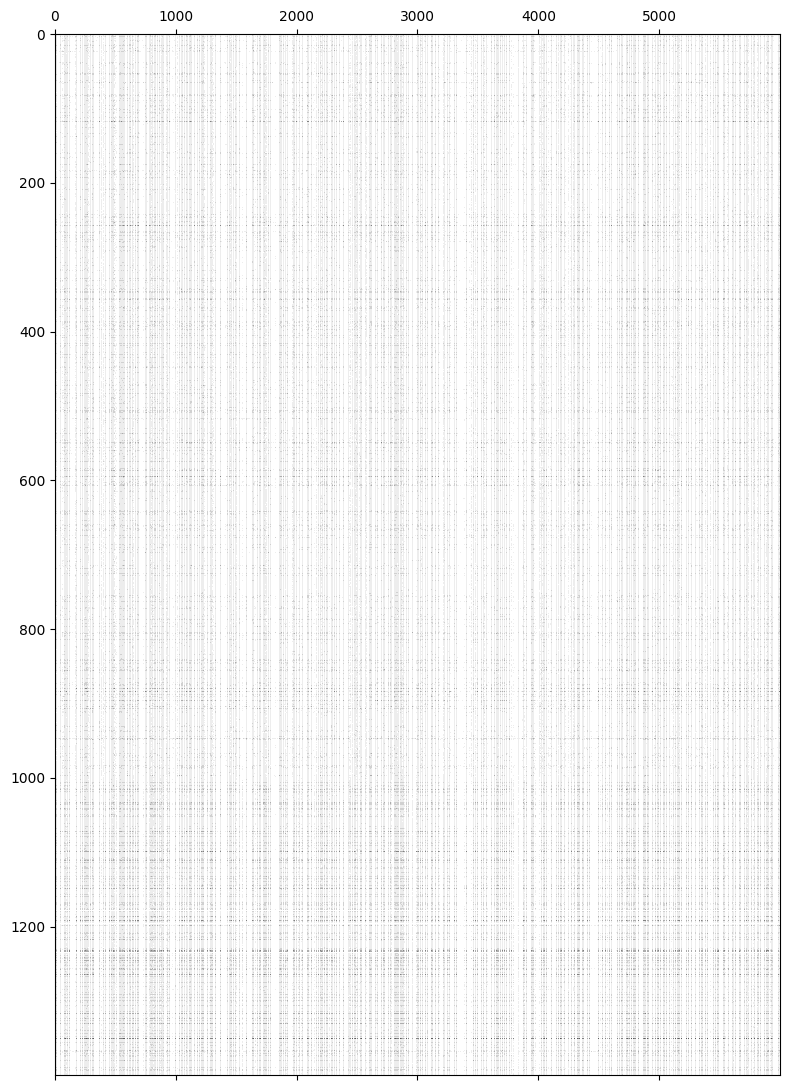

In [49]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(comb, cmap='Greys', aspect='auto')
plt.tight_layout()
plt.show()

In [50]:
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler

#High E, Low PR
#3: synw-6, eep->0.5
_pars = base_pars.copy()
_pars.update({'e-e_synw_u':6,
              'e-e_connectivity_p': 0.5})

E_mat, I_mat = _run(_pars)
comb = np.array(sp.vstack((E_mat,I_mat)).todense())
dt_native = 1/100.0
mat = np.array(sp.vstack((E_mat, I_mat)).todense())
fmat = spk_to_fl(S=mat, dt_native=1/100)
PR, _ = participation_ratio(fmat)
X = fmat.T[200:]
sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=10).fit_transform(sc)
E_mean, _ = E_from_pcs(pca)
print(E_mean, PR)

11.4 1.015047186239324


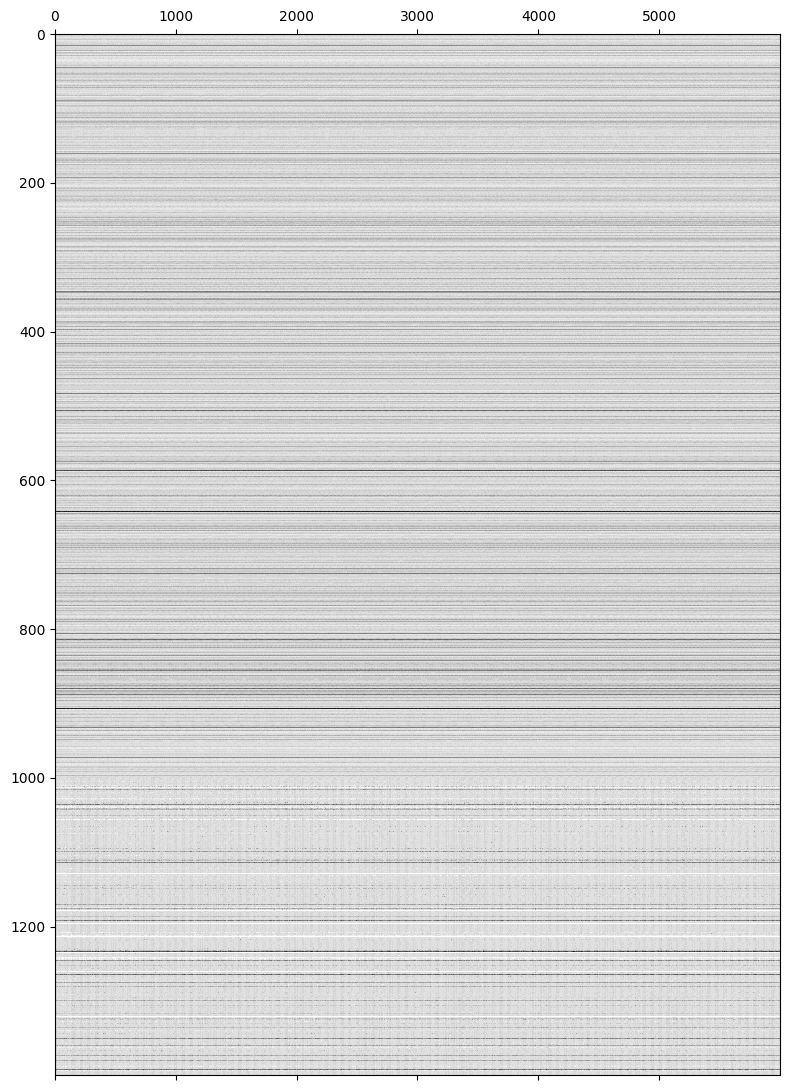

In [51]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(comb, cmap='Greys', aspect='auto')
plt.tight_layout()
plt.show()

In [52]:
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler

#High E, Low PR
#4: synw-1.5, eep->0.5
_pars = base_pars.copy()
_pars.update({'e-e_synw_u':1.5,
              'e-e_connectivity_p': 0.5})

E_mat, I_mat = _run(_pars)
comb = np.array(sp.vstack((E_mat,I_mat)).todense())
dt_native = 1/100.0
mat = np.array(sp.vstack((E_mat, I_mat)).todense())
fmat = spk_to_fl(S=mat, dt_native=1/100)
PR, _ = participation_ratio(fmat)
X = fmat.T[200:]
sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=10).fit_transform(sc)
E_mean, _ = E_from_pcs(pca)
print(E_mean, PR)

4.0 1.01291177644281


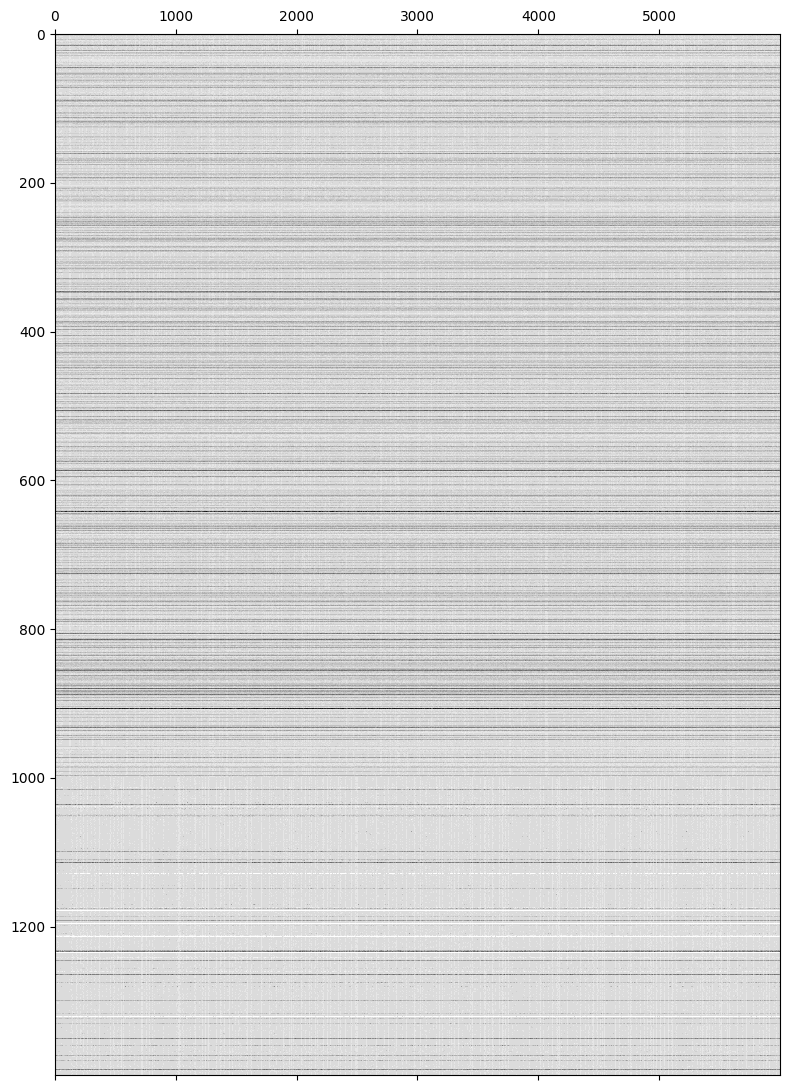

In [53]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(comb, cmap='Greys', aspect='auto')
plt.tight_layout()
plt.show()

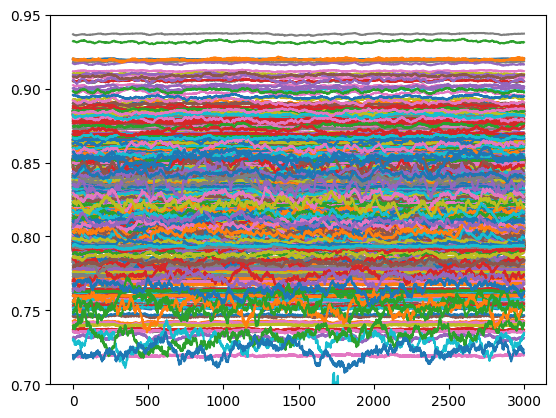

In [58]:
plt.plot(fmat.T[1000:4000])
plt.ylim(0.7,0.95)
plt.show()

In [ ]:
#use model as a way to understand or investigate what is happening in seizures
#or move back into data

In [ ]:
# investigate non-linear structure of the dynamics
# i.e. is high E more non-linear? 